In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

print(os.getcwd())

/Users/arahandoshi/Desktop/computational-biology-cancer-classification/notebooks


In [17]:
expression_df = pd.read_csv(
    "../data/raw/data.csv",
    index_col=0
)

labels_df = pd.read_csv(
    "../data/raw/labels.csv"
)

In [18]:
print(expression_df.shape)
print(labels_df.shape)

(801, 20531)
(801, 2)


In [19]:
import numpy as np

expression_array = expression_df.to_numpy()

print(np.min(expression_array))
print(np.max(expression_array))
print(np.mean(expression_array))
print(np.std(expression_array))

0.0
20.7788287118
6.443322266573218
4.058193683830749


Saving to: /Users/arahandoshi/Desktop/computational-biology-cancer-classification/notebooks/results/figures/eda/gene_expression_histogram.png
File exists after save? False


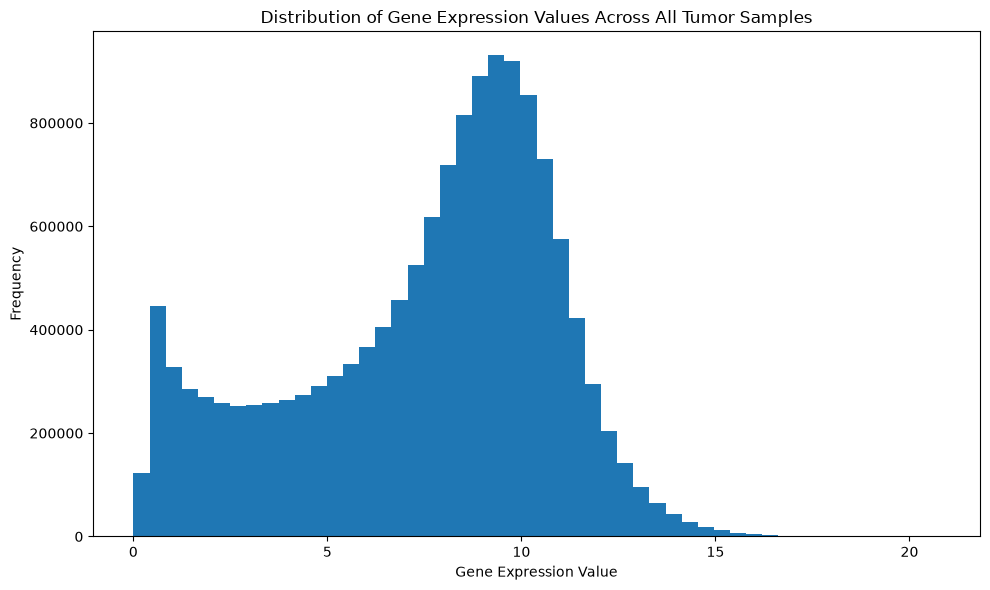

In [32]:
expression_values = expression_array.flatten()

non_zero_expression = expression_values[expression_values > 0]

plt.figure(figsize=(10,6))

plt.hist(non_zero_expression, bins=50)

plt.title("Distribution of Gene Expression Values Across All Tumor Samples")

plt.xlabel("Gene Expression Value")

plt.ylabel("Frequency")

Path("results/figures/eda").mkdir(parents=True, exist_ok=True)

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/raw_gene_expression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/raw_gene_expression_distribution.pdf",
    bbox_inches="tight"
)

import os

print("Saving to:", os.path.abspath("results/figures/eda/gene_expression_histogram.png"))
print("File exists after save?", os.path.exists("results/figures/eda/gene_expression_histogram.png"))

plt.show()
plt.close()

In [12]:
gene_variances = expression_df.var()

print(gene_variances.head())


gene_0    0.018728
gene_1    1.441987
gene_2    1.135506
gene_3    0.408089
gene_4    0.256580
dtype: float64


Saving to: /Users/arahandoshi/Desktop/computational-biology-cancer-classification/notebooks/results/figures/eda/nonzero_expression_distribution.png
File exists after save? False


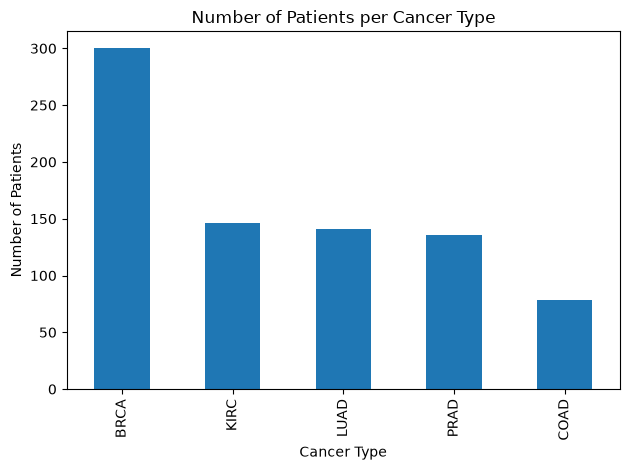

In [33]:
labels_df["Class"].value_counts().plot(kind="bar") 
labels_df["Class"].value_counts().plot(kind="bar") 
plt.title("Number of Patients per Cancer Type") 
plt.xlabel("Cancer Type") 
plt.ylabel("Number of Patients") 

Path("results/figures/eda").mkdir(parents=True, exist_ok=True)

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/nonzero_gene_expression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/nonzero_gene_expression_distribution.pdf",
    bbox_inches="tight"
)

import os

print("Saving to:", os.path.abspath("results/figures/eda/nonzero_expression_distribution.png"))
print("File exists after save?", os.path.exists("results/figures/eda/nonzero_expression_distribution.png"))

plt.show()
plt.close()

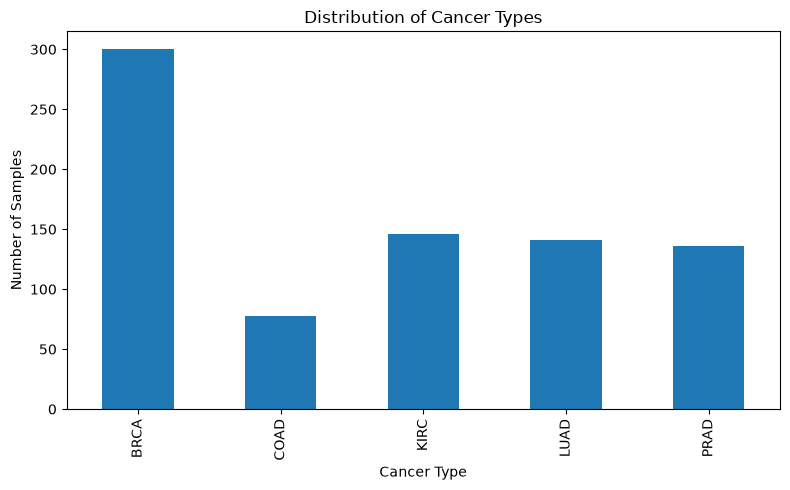

In [34]:
import matplotlib.pyplot as plt

class_counts = labels_df["Class"].value_counts().sort_index()

plt.figure(figsize=(8,5))

class_counts.plot(kind="bar")

plt.title("Distribution of Cancer Types")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/class_distribution.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

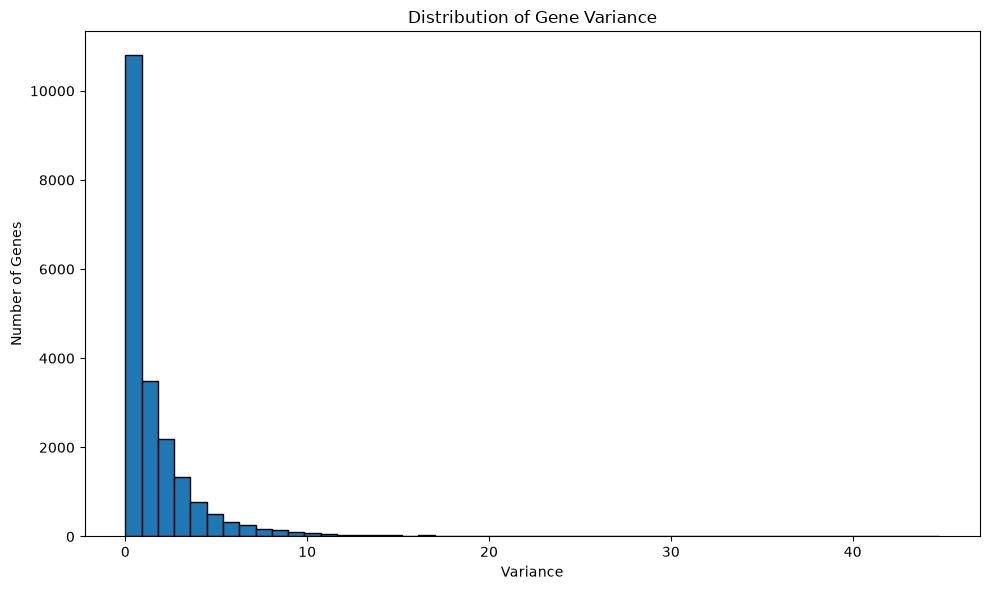

In [35]:
import numpy as np
import matplotlib.pyplot as plt

gene_variance = expression_df.var(axis=0)

plt.figure(figsize=(10,6))

plt.hist(
    gene_variance,
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Gene Variance")
plt.xlabel("Variance")
plt.ylabel("Number of Genes")

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/gene_variance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/gene_variance_distribution.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

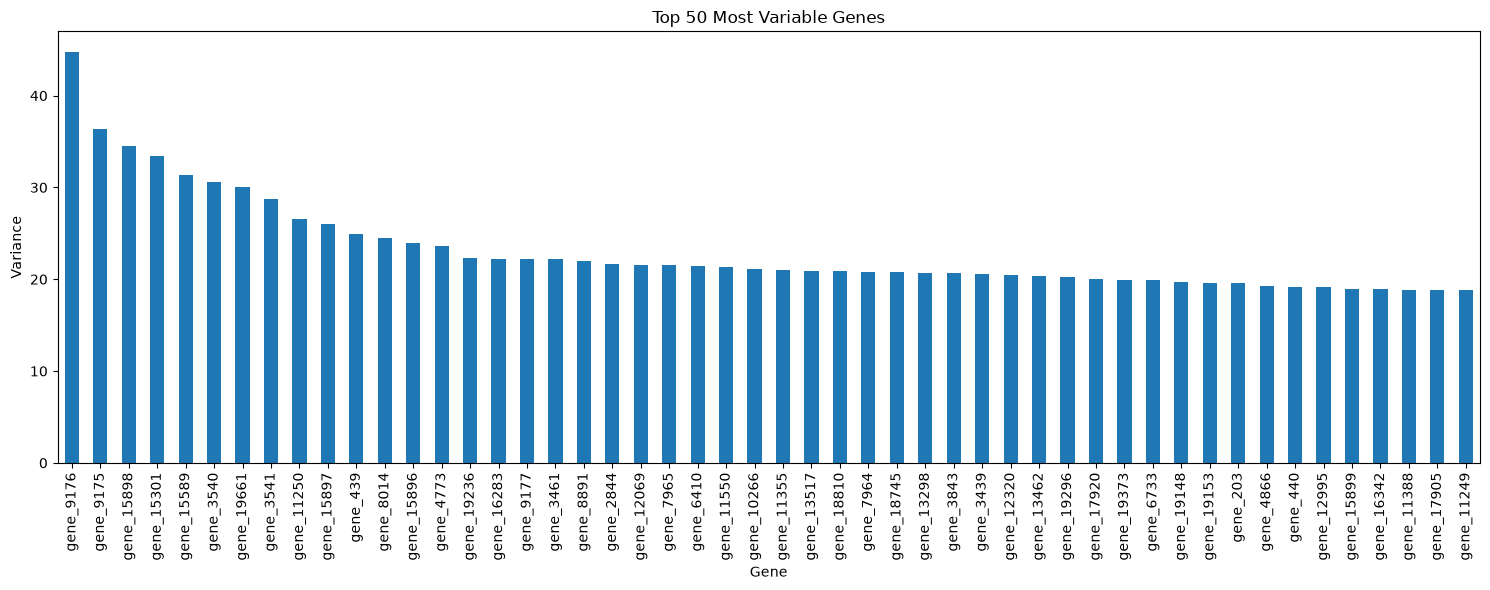

In [36]:
import matplotlib.pyplot as plt

gene_variance = expression_df.var(axis=0)

top_50 = gene_variance.sort_values(ascending=False).head(50)

plt.figure(figsize=(15,6))

top_50.plot(kind="bar")

plt.title("Top 50 Most Variable Genes")
plt.xlabel("Gene")
plt.ylabel("Variance")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/top_50_variable_genes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/top_50_variable_genes.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

scaled_expression = scaler.fit_transform(expression_df)

In [39]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_expression)

In [40]:
import pandas as pd

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pca_df["Cancer"] = labels_df["Class"].values

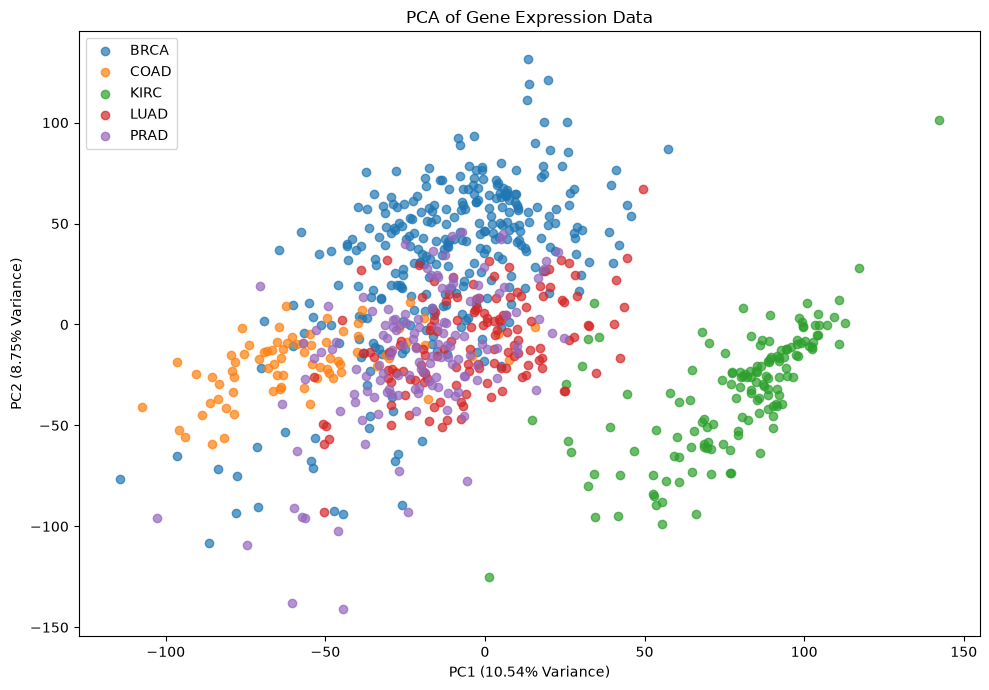

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

cancer_types = sorted(pca_df["Cancer"].unique())

for cancer in cancer_types:
    subset = pca_df[pca_df["Cancer"] == cancer]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=cancer,
        alpha=0.7
    )

plt.title("PCA of Gene Expression Data")
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/pca_scatter_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/pca_scatter_plot.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

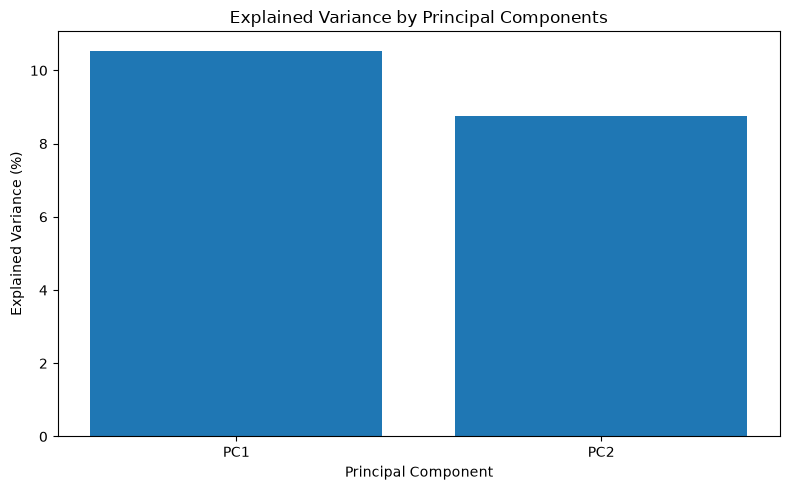

In [42]:
plt.figure(figsize=(8,5))

explained = pca.explained_variance_ratio_ * 100

plt.bar(
    ["PC1","PC2"],
    explained
)

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/pca_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/pca_explained_variance.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

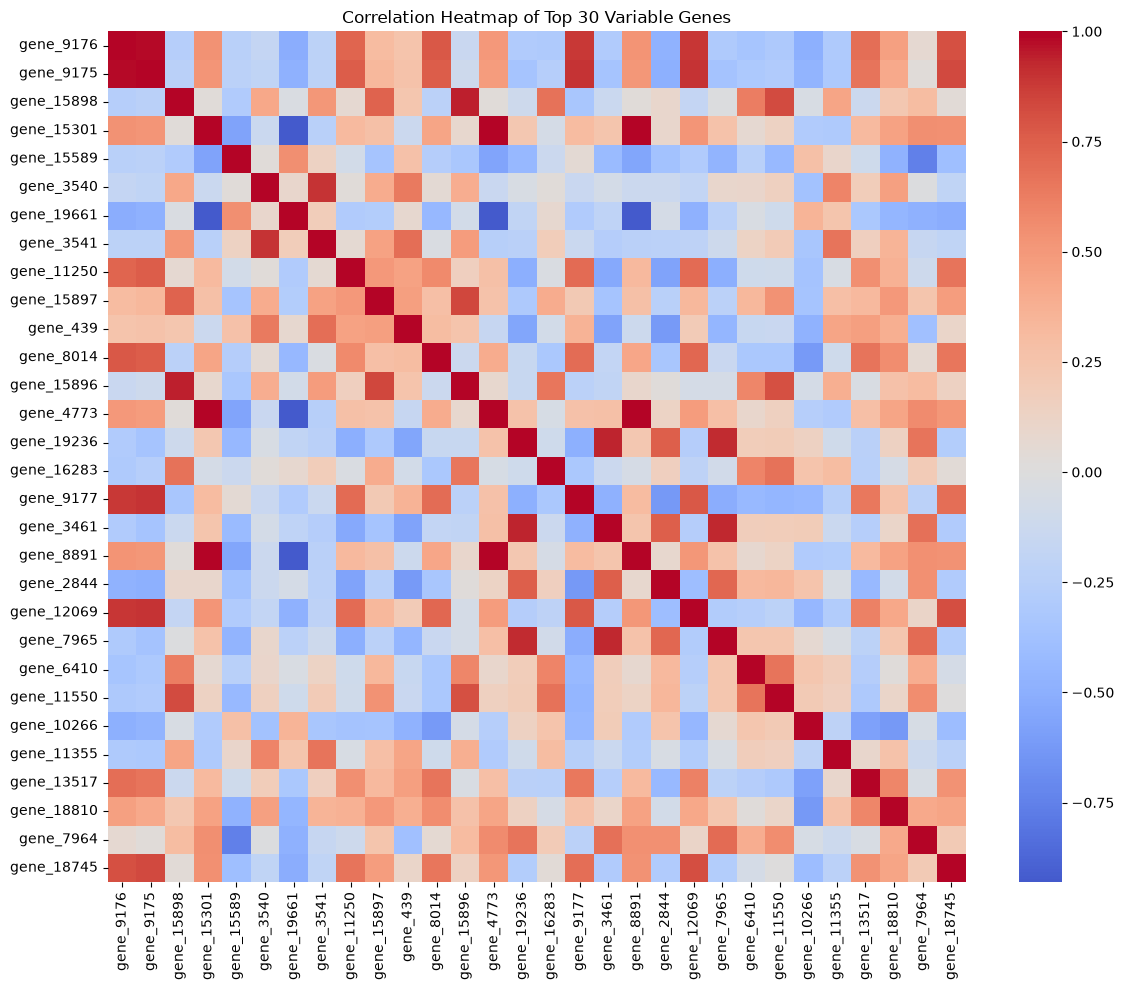

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

top_variable = expression_df.var().sort_values(ascending=False).head(30).index

correlation = expression_df[top_variable].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Top 30 Variable Genes")

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/top30_gene_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/top30_gene_correlation_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [44]:
top50_genes = expression_df.var().sort_values(ascending=False).head(50).index

heatmap_data = expression_df[top50_genes]

/Users/arahandoshi/Desktop/computational-biology-cancer-classification/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/arahandoshi/Desktop/computational-biology-cancer-classification/.venv/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


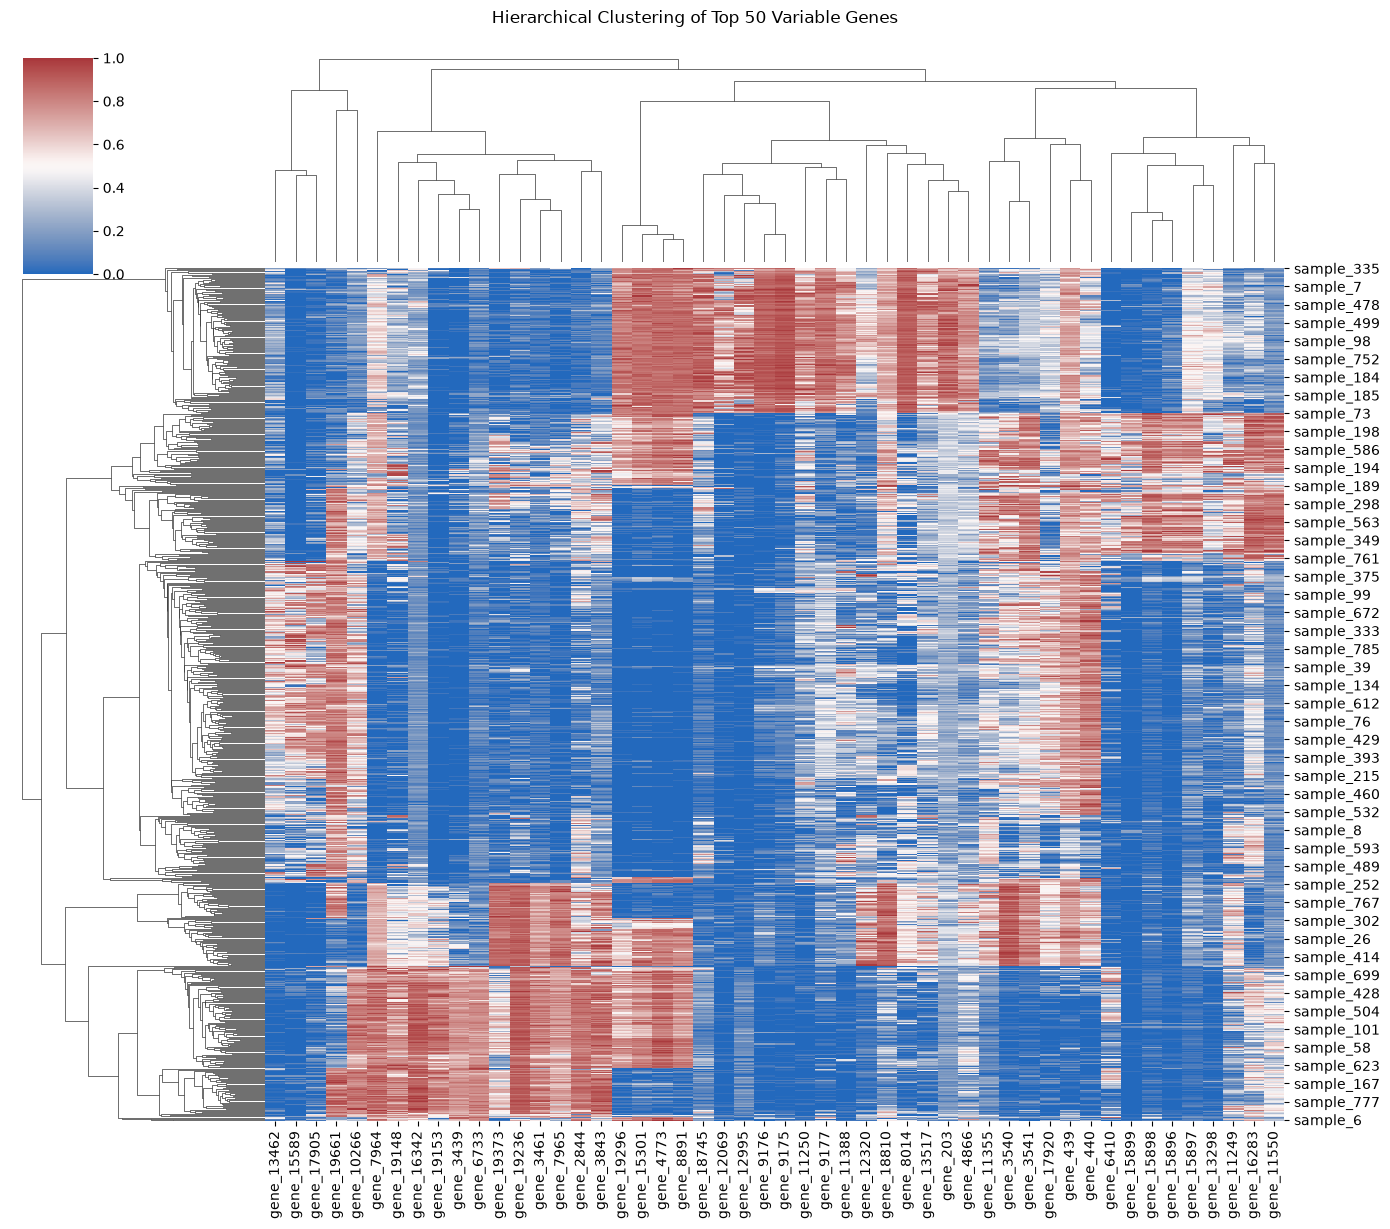

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster = sns.clustermap(
    heatmap_data,
    cmap="vlag",
    figsize=(14,12),
    standard_scale=1,
    method="average"
)

cluster.fig.suptitle(
    "Hierarchical Clustering of Top 50 Variable Genes",
    y=1.02
)

cluster.savefig(
    "../results/figures/eda/hierarchical_clustermap.png",
    dpi=300
)

cluster.savefig(
    "../results/figures/eda/hierarchical_clustermap.pdf"
)

plt.show()
plt.close()

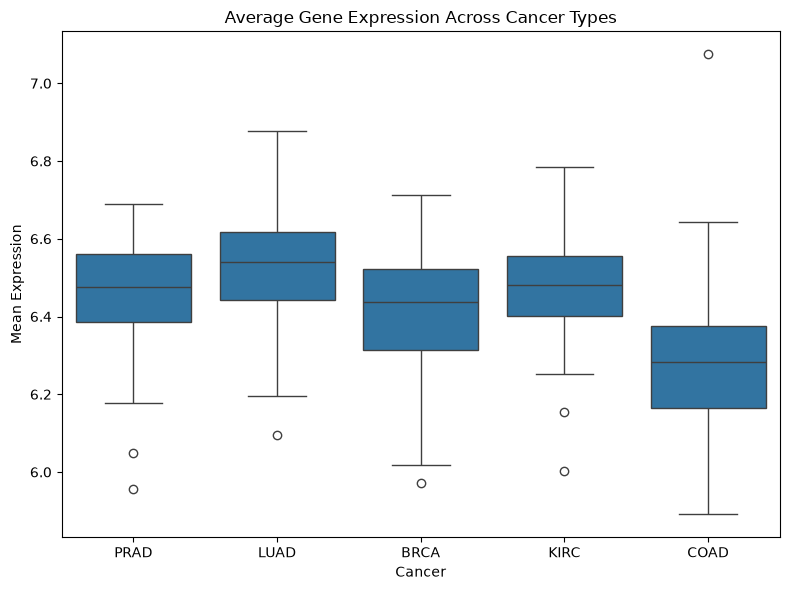

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sample_expression = expression_df.mean(axis=1)

boxplot_df = pd.DataFrame({
    "Cancer": labels_df["Class"].values,
    "Mean Expression": sample_expression
})

plt.figure(figsize=(8,6))

sns.boxplot(
    data=boxplot_df,
    x="Cancer",
    y="Mean Expression"
)

plt.title("Average Gene Expression Across Cancer Types")

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/cancer_expression_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/cancer_expression_boxplot.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [47]:
from sklearn.manifold import TSNE

In [48]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

tsne_result = tsne.fit_transform(scaled_expression)

In [49]:
tsne_df = pd.DataFrame(
    tsne_result,
    columns=["tSNE1", "tSNE2"]
)

tsne_df["Cancer"] = labels_df["Class"].values

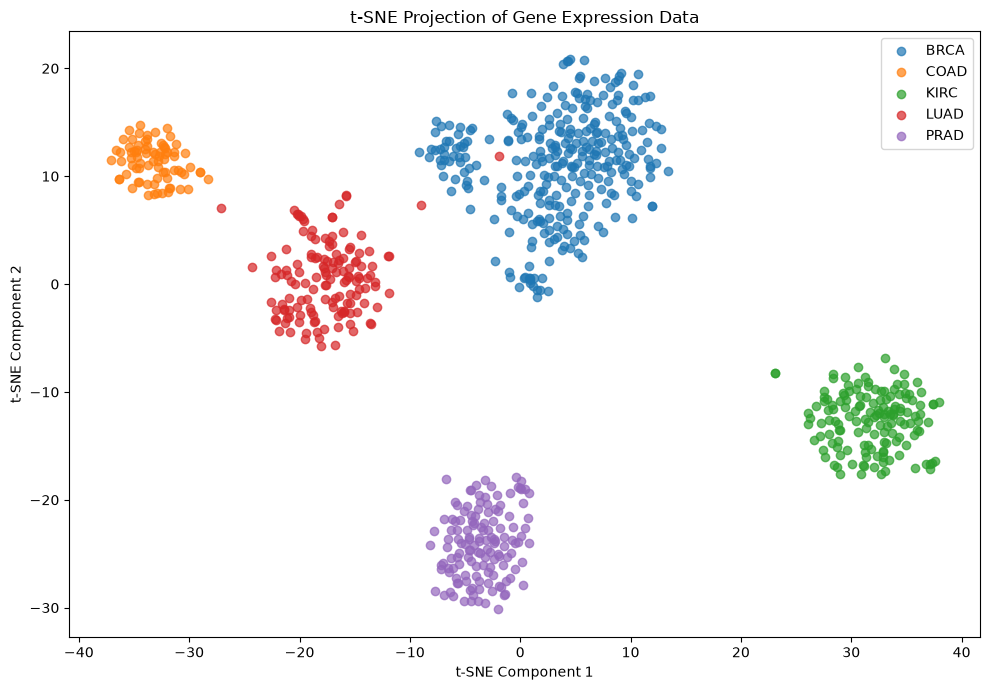

In [50]:
plt.figure(figsize=(10,7))

for cancer in sorted(tsne_df["Cancer"].unique()):

    subset = tsne_df[tsne_df["Cancer"] == cancer]

    plt.scatter(
        subset["tSNE1"],
        subset["tSNE2"],
        label=cancer,
        alpha=0.7
    )

plt.title("t-SNE Projection of Gene Expression Data")

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/tsne_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/tsne_projection.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [51]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [52]:
selector = SelectKBest(
    score_func=f_classif,
    k=50
)

selector.fit(
    scaled_expression,
    labels_df["Class"]
)

/Users/arahandoshi/Desktop/computational-biology-cancer-classification/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [    5    23  4370  4808  4809  4814  4816  4817  4831  5288  7661  7662
  7663  7664  7665  8121  9304  9306  9314  9316  9320  9452 10121 11958
 13991 14158 14159 14161 15138 15140 15141 15446 16566 16568 16569 16571
 16575 16578 16579 16604 16634 16637 16677 16697 16698 16699 16700 16701
 16702 16704 16705 16706 16707 16708 16709 16710 16711 16712 16713 16714
 16715 16716 16717 16718 16719 16720 16721 16722 16723 16724 16725 16726
 16727 16728 16729 16730 16731 16732 16733 16734 16735 16736 16737 16738
 16739 16740 16741 16742 16743 16744 16745 16746 16748 16749 16750 16751
 16752 16753 16754 16756 16757 16758 16759 16760 16761 16762 16763 16764
 16765 16766 16767 16768 16769 16770 16771 16772 16774 16775 16776 16777
 16778 16779 16780 16781 16782 16783 16785 16787 16788 16789 16790 16791
 16792 16794 

SelectKBest(k=50)

In [ ]:
#10 most informative gene values.

feature_scores = pd.DataFrame({
    "Gene": expression_df.columns,
    "F_score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="F_score",
    ascending=False
)

feature_scores.head(10)

,Gene,F_score
9175,gene_9175,4194.489336
9176,gene_9176,3463.550328
220,gene_220,3441.768332
219,gene_219,3391.740121
18135,gene_18135,2772.293045
13818,gene_13818,2438.581553
14114,gene_14114,2409.065626
450,gene_450,2215.236357
7964,gene_7964,2055.979393
3737,gene_3737,2046.827137


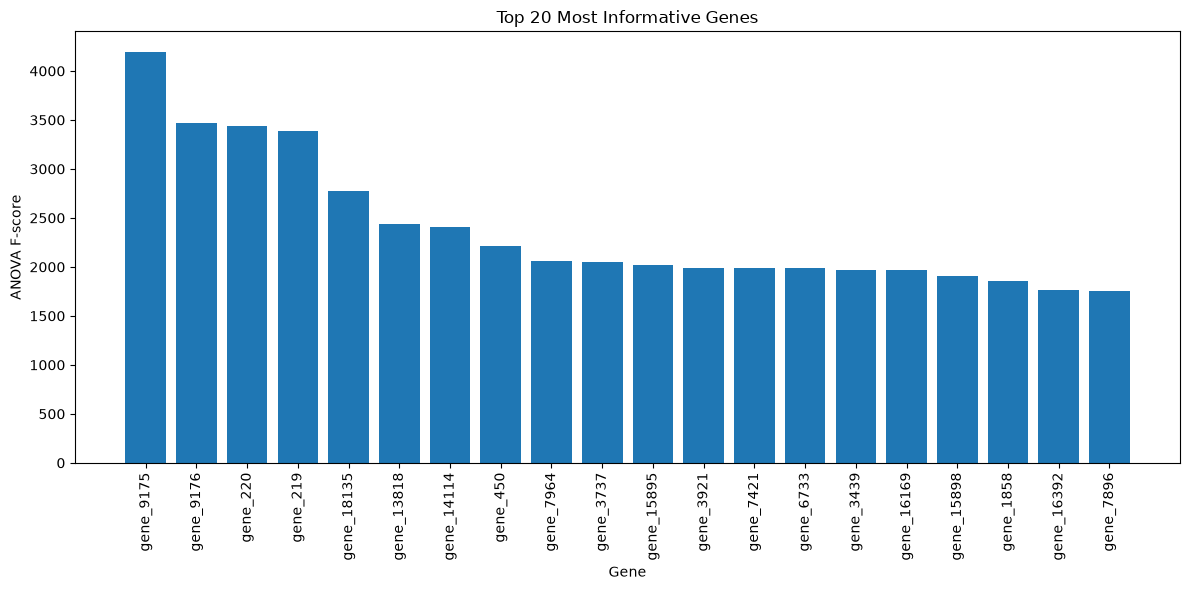

In [54]:
plt.figure(figsize=(12,6))

top20 = feature_scores.head(20)

plt.bar(
    top20["Gene"],
    top20["F_score"]
)

plt.xticks(rotation=90)

plt.xlabel("Gene")
plt.ylabel("ANOVA F-score")

plt.title("Top 20 Most Informative Genes")

plt.tight_layout()

plt.savefig(
    "../results/figures/eda/top20_informative_genes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "../results/figures/eda/top20_informative_genes.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [55]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [56]:
selector = SelectKBest(
    score_func=f_classif,
    k=500
)

selected_features = selector.fit_transform(
    scaled_expression,
    labels_df["Class"]
)

/Users/arahandoshi/Desktop/computational-biology-cancer-classification/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [    5    23  4370  4808  4809  4814  4816  4817  4831  5288  7661  7662
  7663  7664  7665  8121  9304  9306  9314  9316  9320  9452 10121 11958
 13991 14158 14159 14161 15138 15140 15141 15446 16566 16568 16569 16571
 16575 16578 16579 16604 16634 16637 16677 16697 16698 16699 16700 16701
 16702 16704 16705 16706 16707 16708 16709 16710 16711 16712 16713 16714
 16715 16716 16717 16718 16719 16720 16721 16722 16723 16724 16725 16726
 16727 16728 16729 16730 16731 16732 16733 16734 16735 16736 16737 16738
 16739 16740 16741 16742 16743 16744 16745 16746 16748 16749 16750 16751
 16752 16753 16754 16756 16757 16758 16759 16760 16761 16762 16763 16764
 16765 16766 16767 16768 16769 16770 16771 16772 16774 16775 16776 16777
 16778 16779 16780 16781 16782 16783 16785 16787 16788 16789 16790 16791
 16792 16794 

In [ ]:
#selection of top 500 genes on basis of expression

selected_gene_names = expression_df.columns[
    selector.get_support()
]

selected_df = pd.DataFrame(
    selected_features,
    columns=selected_gene_names
)

selected_df.head()

,gene_18,gene_30,gene_89,gene_145,gene_148,gene_172,gene_180,gene_203,gene_219,gene_220,...,gene_19343,gene_19356,gene_19373,gene_19563,gene_19606,gene_19623,gene_19669,gene_19914,gene_20109,gene_20392
0,-0.505034,-0.67726,1.516819,-0.475966,1.424400,-0.645154,-0.763433,1.984468,-0.387755,-0.358341,...,-1.134947,-1.336288,-0.855460,-0.441729,0.970637,0.512787,-0.356919,1.182970,2.082179,2.197140
1,-0.690400,-0.67726,-0.177722,-1.135238,-0.148359,-0.021470,-0.281669,0.517840,-0.524226,-0.499892,...,0.053522,1.312236,-0.673612,0.526061,-2.352941,0.981737,2.685164,-1.045046,-0.850739,-0.573696
2,-0.163300,-0.67726,1.774966,0.620564,1.782174,-0.473261,-0.763433,1.562135,-0.524226,-0.391650,...,-1.782647,-2.178225,-0.411317,-1.575369,0.686569,1.269663,-0.800249,0.501575,-0.702915,-0.034494
3,-0.293481,-0.67726,2.200414,-0.369190,1.525949,-0.823732,-0.763433,2.391221,-0.284561,-0.395886,...,-0.907411,-1.016637,-0.683152,-0.873432,0.973071,0.312708,-0.870923,1.151039,1.518095,1.115477
4,-0.411756,-0.67726,-1.116671,-0.607646,-1.025924,-0.622586,0.173163,-0.641506,-0.524226,-0.499892,...,-0.300383,0.835965,-0.855460,0.066528,0.812776,0.905973,-0.062638,1.075517,-0.025054,0.062227


In [58]:
selected_df.to_csv(
    "../data/processed/top500_gene_expression.csv",
    index=False
)

print("Top 500 gene dataset saved.")

Top 500 gene dataset saved.
